#  Request and format ParFlow simulation results

In this notebook, we will request ParFlow-CONUS1 simulation results via the hf_hydrodata Python package. We'll use these pre-computed simulations to compare against observations.

*Note:* If you'd like to run your own ParFlow simulations for a specific HUC region (including those within the CONUS2 domain) and time period, then feel free to explore our [SubsetTools Python package](https://hydroframesubsettools.readthedocs.io/en/latest/). The documentation includes full example notebooks for accessing data, setting parameters, and conducting your own ParFlow simulation.

### Set-Up

In [8]:
import datetime
import numpy as np
import pandas as pd
import hf_hydrodata as hf

You'll need to register for a HydroFrame Account and PIN in order to use the `hf_hydrodata` package. The [Getting Started page](https://hf-hydrodata.readthedocs.io/en/latest/getting_started.html) has full details on how to sign up for an account and set up a PIN.

Once you create a PIN, you'll need to register your PIN.

In [ ]:
hf.register_api_pin("your_email", "your_api_pin")

*Note*: Data requested from the `hf_hydroata` gridded module is returned in NumPy arrays. 

### Example: Request ParFlow-CONUS1 outputs for WY2003 for HUC 14020001

Let's start by requesting the observations data we're interested in comparing against. Here we'll be comparing site-by-site against the corresponding ParFlow-CONUS1 grid cell that each site maps to.

As a project, we have pre-computed the ParFlow grid cell mappings for every stream gage, groundwater well, SNOTEL station, SCAN station, and AmeriFlux site. Those are stored in the variables `conus1_i` and `conus1_j` for the ParFlow-CONUS1 grid and `conus2_i` and `conus2_j` for the ParFlow-CONUS2 grid. In this example, we will use those grid indices directly. Please see the `parflow_grid_mapping.ipynb` notebook in this same directory for more details on how we constructed those mappings.

In [16]:
point_options = {
    "dataset": "snotel",
    "variable": "swe",
    "temporal_resolution": "daily",
    "aggregation": "sod",
    "huc_id": ["14020001"], 
    "grid": "conus1",
    "date_start": "2002-10-01",
    "date_end": "2003-09-30"}

obs_metadata_df = hf.get_point_metadata(point_options)
obs_data_df = hf.get_point_data(point_options)

obs_metadata_df.loc[:, ["site_id", "site_name", "latitude", "longitude", "conus1_i", "conus1_j"]]

,site_id,site_name,latitude,longitude,conus1_i,conus1_j
0,380:CO:SNTL,Butte,38.89435,-106.95327,942.0,650.0
1,680:CO:SNTL,Park Cone,38.81982,-106.58962,972.0,638.0


Now that we know where our sites are located, we're going to extract only those grid cells. The ParFlow-CONUS1 simulation results are a gridded dataset, so we'll use the `get_gridded_data` function. This function takes inputs similar to the `get_point_data` function; sometimes fewer parameters are needed. We'll request from the [ParFlow-CONUS1 modern simulations](https://hf-hydrodata.readthedocs.io/en/latest/gen_conus1_baseline_mod.html) dataset.
- `dataset="conus1_baseline_mod"`
- `variable="swe"`
- `temporal_resolution="daily"`
- `date_start="2002-10-01"`
- `date_end="2003-10-01"`

**Note**: The `get_gridded_data` function follows NumPy indexing convention. The end date will be exclusive of the request. We are working on updating the point module to be consistent with this convention. For now, set the start and end dates separately within each query.

Because there are only specific locations we want to extract, we'll use the `grid_point` parameter to extract the grid cell associated with each site. As a reminder, the [Python API reference](https://hf-hydrodata.readthedocs.io/en/latest/api_reference.html) has complete information on available parameter options.

In [12]:
date_start = datetime.datetime(2002, 10, 1)
date_end = datetime.datetime(2003, 9, 30)

# Create DataFrame for storing ParFlow results
timesteps = np.arange(
            date_start,
            date_end + datetime.timedelta(days=1),
            datetime.timedelta(days=1)).astype("datetime64[D]")

model_df = pd.DataFrame(columns=["date"], data=timesteps)
model_df.head(5)

,date
0,2002-10-01
1,2002-10-02
2,2002-10-03
3,2002-10-04
4,2002-10-05


In [ ]:
#  Loop over each station in obs_metadata_df
for idx, row in obs_metadata_df.iterrows():
    site_id = row["site_id"]  # original SNTL site_id
    conus_i = int(row["conus1_i"])
    conus_j = int(row["conus1_j"])
    
    # Build options dict for this station
    options = {
        "dataset": "conus1_baseline_mod",
        "variable": "swe",
        "temporal_resolution": "daily",
        "start_time": date_start,
        "end_time": date_end + datetime.timedelta(days=1),  ### NOTE: the gridded function has exclusive end date
        "grid_point": [conus_i, conus_j]
    }
    
    # Get gridded data
    data = hf.get_gridded_data(options)
    
    # Fill column in model_df
    # Convert to numeric in case hf returns lists or other types
    model_df[site_id] = np.squeeze(np.array(data))



In [14]:
model_df.head(5)

,date,380:CO:SNTL,680:CO:SNTL
0,2002-10-01,0.000000,0.0
1,2002-10-02,0.000000,0.0
2,2002-10-03,4.598256,0.0
3,2002-10-04,1.143077,0.0
4,2002-10-05,0.000000,0.0


Great! Now we have our ParFlow results in the same format as our observations data. Let's do some quick plots to compare.

In [18]:
obs_data_df.head(5)

,date,380:CO:SNTL,680:CO:SNTL
0,2002-10-01,0.00,0.0
1,2002-10-02,0.00,0.0
2,2002-10-03,0.00,0.0
3,2002-10-04,10.16,0.0
4,2002-10-05,7.62,0.0


In [19]:
from cssi_evaluation.plots import plot_time_series

In [ ]:
# The resulting plots will be saved to the current working directory.
plot_time_series(
    obs_data_df,
    model_df,
    obs_metadata_df,
    variable="swe")

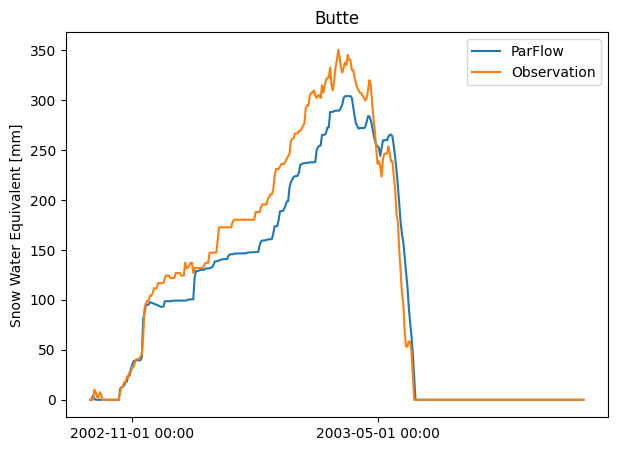

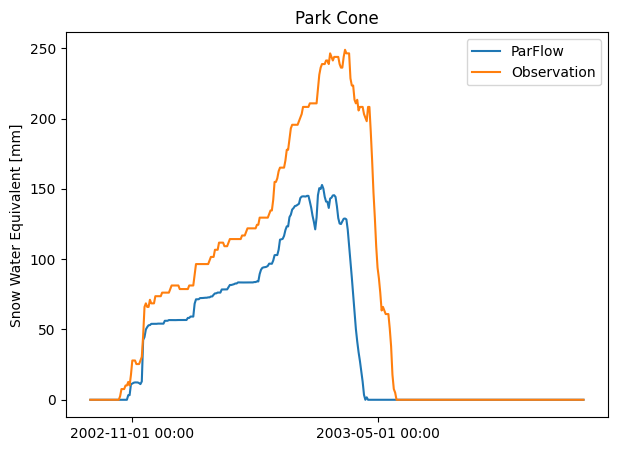

In [ ]:
# Optional: view saved plots in the notebook
from IPython.display import display, Image

for site_id in list(obs_metadata_df["site_id"]):
    img = f"swe_{site_id}.png"
    display(Image(filename=img))

In [23]:
hf.get_citations(dataset="conus1_baseline_mod")

'None\n  Source: https://doi.org/10.5194/gmd-14-7223-2021\n'